In [2]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import pickle as pkl
import math
import glob
import re
sns.set(style='whitegrid')

In [3]:
results_val = {}
results_tr = {}

In [4]:
def grab_data(wid_exp, lrs, seeds, time, depth, act = lambda x: x // 4): #operates on results_val and results_tr in place
    for lr in lrs:
        for width, num_exp, _ in wid_exp:
                num_act = act(num_exp)
                for seed in seeds:
                    print()
                    file_name = f'../run_data/mutransfer_lr_cccc/out_{time}/width{width}_depth{depth}_experts{num_exp}_active{num_act}_seed{seed}_lr{lr}_alpha1.0_mult0.5/log.csv'
                    if os.path.exists(file_name):
                        try:
                            csv_df = pd.read_csv(file_name)
                        except:
                            print(f"File {file_name} is corrupted, skipping")
                            results_val[(width, num_exp, num_act, seed, lr)] = 10.0
                            results_tr[(width, num_exp, num_act, seed, lr)] = 10.0
                            continue
                        val_loss = csv_df.iloc[-1]['val/loss']
                        if val_loss > 0.0:
                            avg_train_loss = np.mean(csv_df['train/loss'][-50:])
                            print(f"result found for {file_name}, val_loss achieved {val_loss}")
                            print(f"average training loss for last 50 steps: {avg_train_loss}")
                            results_val[(width, num_exp, num_act, seed, lr)] = val_loss
                            results_tr[(width, num_exp, num_act, seed, lr)] = avg_train_loss
                        else:
                            print(f"No validation loss found for {file_name}, trial ended at iteration {csv_df.shape[0]}")
                            print(f"Lowest traininig loss achieved: {np.min(csv_df['train/loss'])}")
                    else:
                        print(f"File {file_name} does not exist, check your path")

def max_deviation_last_checkpoint(filename):
    '''
    max_deviation_last_checkpoint("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20251016_025824/stdout/job_0003_gpu3_w768_exp48_lr4.00e-03_seed1_alpha1.0_mult0.5.log") 
    0.016
    '''
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()
    matches = list(re.finditer(r"Validation - step\s+\d+", text))
    if not matches:
        raise ValueError("No 'Validation - step' found in file.")
    start_idx = matches[-1].start()
    tail = text[start_idx:]
    deviations = re.findall(
        r"^L\d+:[^\n]*?max_deviation=([0-9]+(?:\.[0-9]+)?)",
        tail,
        flags=re.M
    )
    if not deviations:
        raise ValueError("No 'max_deviation' entries found after last checkpoint.")
    return max(map(float, deviations))

def plot_results(result, title = ""):
    plt.figure(figsize=(10, 6))
    config_results = {}
    for (width, num_exp, num_act, seed, lr), mse in result.items():
        config = (num_exp, num_act, width)
        if config not in config_results:
            config_results[config] = []
        config_results[config].append((lr, mse))
    averaged_results = {}
    for config, pts in config_results.items():
        lr_to_mses = {}
        for lr, mse in pts:
            if lr not in lr_to_mses:
                lr_to_mses[lr] = []
            lr_to_mses[lr].append(mse)
        averaged_pts = []
        for lr in sorted(lr_to_mses.keys()):
            avg_mse = np.mean(lr_to_mses[lr])
            averaged_pts.append((lr, avg_mse))
        averaged_results[config] = averaged_pts
    total_experiments = len(result)
    print(f"Total experiments: {total_experiments}")
    print("\nResults by configuration:")
    for (n_exp, num_act, width), pts in sorted(averaged_results.items()):
        valid_pts = [(lr, mse) for lr, mse in pts if not math.isnan(mse)]
        print(f"  n={n_exp}, n_act={num_act}, width={width}: {len(valid_pts)} valid lr points")
        if valid_pts:
            best_lr, best_mse = min(valid_pts, key=lambda x: x[1])
            print(f"    Best: lr={best_lr:.3e}, MSE={best_mse:.6f}")
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h']
    
    for idx, ((n_exp, num_act ,width), pts) in enumerate(sorted(averaged_results.items())):
        if pts:
            # Sort by lr for proper line plotting
            pts_sorted = sorted(pts, key=lambda t: t[0])
            lrs_plot, mses = zip(*pts_sorted)
            
            # Filter out NaN values
            valid_pts = [(lr, mse) for lr, mse in zip(lrs_plot, mses) if not math.isnan(mse)]
            
            if valid_pts:
                valid_lrs, valid_mses = zip(*valid_pts)
                color = colors[idx % len(colors)]
                marker = markers[idx % len(markers)]
                plt.plot(valid_lrs, valid_mses, marker=marker, color=color,
                        label=f'n_exp={n_exp}, n_act={num_act}, width={width}', linewidth=1.5, markersize=6,
                        alpha=0.8)
                
                # Mark the best point with a star
                best_idx = np.argmin(valid_mses)
                plt.scatter(valid_lrs[best_idx], valid_mses[best_idx], 
                           s=200, color=color, marker='*', edgecolor='black', 
                           linewidth=2, zorder=10)

    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.ylim(3.1, 4.1)
    plt.xlabel(r'Learning rate', fontsize=12)
    plt.ylabel('log perplexity', fontsize=12)
    plt.title(f'Hyperparameter Transfer Results ' + title, 
              fontsize=14)
    plt.legend(fontsize=10, loc='best', ncol=2)
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    
    # Save plot
    plot_dir = "plots"
    os.makedirs(plot_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_name = os.path.join(plot_dir, f"hp_transfer_plot_5kit_alt_{timestamp}.png")
    plt.savefig(plot_name, dpi=150, bbox_inches='tight')
    print(f"\nPlot saved as: {plot_name}")
    plt.show()
    return averaged_results

def get_filenames_in_dir(directory_path):
    '''
    get_filenames_in_dir("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/"+time+"/stdout")
    ['job_0007_gpu7_w384_exp64_lr6.40e-02_seed1_alpha1.0_mult0.0.log',
    'job_0002_gpu2_w384_exp64_lr2.00e-03_seed1_alpha1.0_mult0.0.log',
    'job_0000_gpu0_w384_exp64_lr5.00e-04_seed1_alpha1.0_mult0.0.log',
    'job_0005_gpu5_w384_exp64_lr1.60e-02_seed1_alpha1.0_mult0.0.log',
    'job_0006_gpu6_w384_exp64_lr3.20e-02_seed1_alpha1.0_mult0.0.log',
    'job_0004_gpu4_w384_exp64_lr8.00e-03_seed1_alpha1.0_mult0.0.log',
    'job_0003_gpu3_w384_exp64_lr4.00e-03_seed1_alpha1.0_mult0.0.log',
    'job_0001_gpu1_w384_exp64_lr1.00e-03_seed1_alpha1.0_mult0.0.log']
    '''
    try:
        filenames = os.listdir(directory_path)
        return filenames
    except FileNotFoundError:
        print(f"Directory not found: {directory_path}")
        return []

def find_job_file(base_path, time_dir, job_prefix):
    '''
    find_job_file("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/", '20251015_032643', 'job_0007_gpu7_w384_exp64_lr6.40e-02_seed1_alpha1.0_mult0.0.log') 
    ('job_0007_gpu7_w384_exp64_lr6.40e-02_seed1_alpha1.0_mult0.0.log',
    {'width': 384,
    'num_exp': 64,
    'lr': 0.064,
    'seed': 1,
    'alpha': 1.0,
    'mult': 0.0})
    '''
    search_pattern = os.path.join(base_path, time_dir, "stdout", f"{job_prefix}")
    matches = glob.glob(search_pattern)
    if not matches:
        return None, None
    full_path = matches[0]
    filename = os.path.basename(full_path)
    pattern = r'job_\d+_gpu\d+_w(\d+)_exp(\d+)_lr([\d.e\-+]+)_seed(\d+)_alpha([\d.]+)_mult([\d.]+)\.log'
    match = re.match(pattern, filename)
    if not match:
        return filename, None
    params = {
                       'width': int(match.group(1)),
                       'num_exp': int(match.group(2)),
                       'lr': float(match.group(3)),
                       'seed': int(match.group(4)),
                       'alpha': float(match.group(5)),
                       'mult': float(match.group(6))
            }
    return filename, params

def parse_validation_loss(log_file_path): 
    '''
    result = parse_validation_loss("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20250930_041850/stdout/job_0006_gpu6_w512_exp4_lr2.00e-03_seed3.log")
    {1: 10.8439, 1001: 5.4033, 2001: 4.6293, 3001: 4.3399, 4001: 4.1837, 5001: 4.0975, 6001: 4.0193, 7001: 3.965, 8001: 3.9159, 9001: 3.8888, 10001: 3.884}
    '''
    result = {}
    pattern = r'Validation - step (\d+): val loss ([\d.]+)'

    try:
        with open(log_file_path, 'r') as f:
            for line in f:
                match = re.search(pattern, line)
                if match:
                    step = int(match.group(1))
                    loss = float(match.group(2))
                    result[step] = loss
    except FileNotFoundError:
        print(f"Error: File {log_file_path} not found")
        return {}
    except Exception as e:
        print(f"Error reading file: {e}")
        return {}
    return result

In [5]:
wid_exp = [(768, 12, 20), (768, 8, 20), (384, 8, 10), (1024, 8, 20), (384, 12, 10)]
lrs = [0.0005, 0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, ]
seeds = [1]
depth = 14
time = '20251017_041209'
grab_data(wid_exp, lrs, seeds, time, depth)


result found for ../run_data/mutransfer_lr_cccc/out_20251017_041209/width768_depth14_experts12_active3_seed1_lr0.0005_alpha1.0_mult0.5/log.csv, val_loss achieved 3.6745777130126953
average training loss for last 50 steps: 3.6721715927124015

result found for ../run_data/mutransfer_lr_cccc/out_20251017_041209/width768_depth14_experts8_active2_seed1_lr0.0005_alpha1.0_mult0.5/log.csv, val_loss achieved 3.71657657623291
average training loss for last 50 steps: 3.7145378589630127

result found for ../run_data/mutransfer_lr_cccc/out_20251017_041209/width384_depth14_experts8_active2_seed1_lr0.0005_alpha1.0_mult0.5/log.csv, val_loss achieved 3.886339664459229
average training loss for last 50 steps: 3.8812198638916016

result found for ../run_data/mutransfer_lr_cccc/out_20251017_041209/width1024_depth14_experts8_active2_seed1_lr0.0005_alpha1.0_mult0.5/log.csv, val_loss achieved 3.671734571456909
average training loss for last 50 steps: 3.668204545974731

result found for ../run_data/mutransfe

In [6]:
wid_exp = [(384, 64, 10)]
time = '20251017_230151'
grab_data(wid_exp, lrs, seeds, time, depth)


result found for ../run_data/mutransfer_lr_cccc/out_20251017_230151/width384_depth14_experts64_active16_seed1_lr0.0005_alpha1.0_mult0.5/log.csv, val_loss achieved 3.693471670150757
average training loss for last 50 steps: 3.6881582736968994

result found for ../run_data/mutransfer_lr_cccc/out_20251017_230151/width384_depth14_experts64_active16_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.5777294635772705
average training loss for last 50 steps: 3.572595596313477

result found for ../run_data/mutransfer_lr_cccc/out_20251017_230151/width384_depth14_experts64_active16_seed1_lr0.002_alpha1.0_mult0.5/log.csv, val_loss achieved 3.494024991989136
average training loss for last 50 steps: 3.488802433013916

result found for ../run_data/mutransfer_lr_cccc/out_20251017_230151/width384_depth14_experts64_active16_seed1_lr0.004_alpha1.0_mult0.5/log.csv, val_loss achieved 3.451181173324585
average training loss for last 50 steps: 3.445517063140869

result found for ../run_data/mutrans

Total experiments: 46

Results by configuration:
  n=8, n_act=2, width=384: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.654854
  n=8, n_act=2, width=768: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.426600
  n=8, n_act=2, width=1024: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.375883
  n=12, n_act=3, width=384: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.607776
  n=12, n_act=3, width=768: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.400567
  n=64, n_act=16, width=384: 6 valid lr points
    Best: lr=8.000e-03, MSE=3.434311



Plot saved as: plots/hp_transfer_plot_5kit_alt_20251018_203311.png


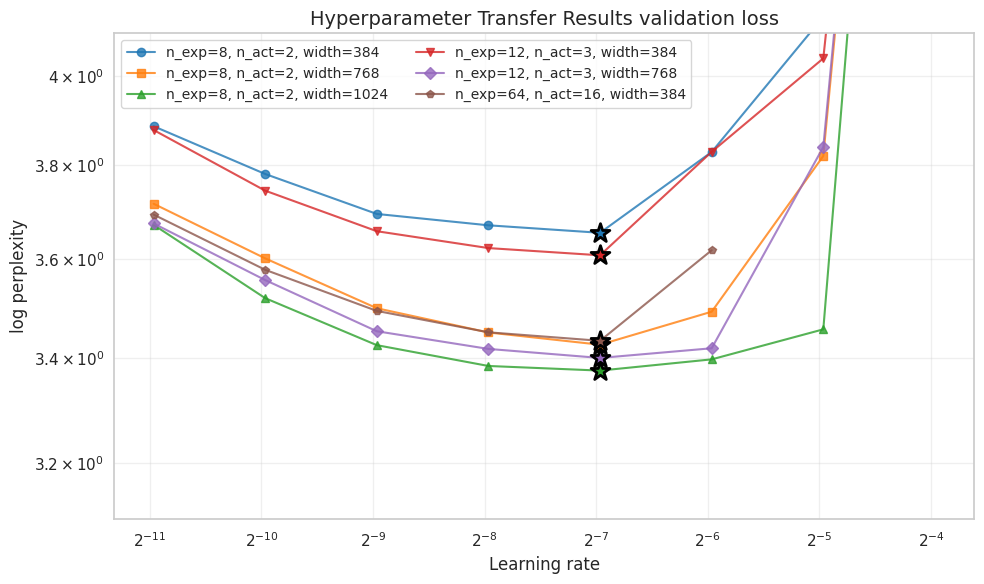

{(12, 3, 768): [(0.0005, np.float64(3.6745777130126953)),
  (0.001, np.float64(3.556647539138794)),
  (0.002, np.float64(3.4532926082611084)),
  (0.004, np.float64(3.418297052383423)),
  (0.008, np.float64(3.4005672931671143)),
  (0.016, np.float64(3.419577121734619)),
  (0.032, np.float64(3.840049743652344)),
  (0.064, np.float64(7.5647125244140625))],
 (8, 2, 768): [(0.0005, np.float64(3.71657657623291)),
  (0.001, np.float64(3.601401090621948)),
  (0.002, np.float64(3.4993927478790283)),
  (0.004, np.float64(3.450833320617676)),
  (0.008, np.float64(3.4265999794006348)),
  (0.016, np.float64(3.4923884868621826)),
  (0.032, np.float64(3.8202579021453857)),
  (0.064, np.float64(7.511003017425537))],
 (8, 2, 384): [(0.0005, np.float64(3.886339664459229)),
  (0.001, np.float64(3.780805349349976)),
  (0.002, np.float64(3.694765090942383)),
  (0.004, np.float64(3.6706557273864746)),
  (0.008, np.float64(3.654853820800781)),
  (0.016, np.float64(3.829075813293457)),
  (0.032, np.float64(4.

In [7]:
plot_results(results_val, title = "validation loss")